**K_Means Clustering from stratch**

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Load dataset
df = pd.read_csv("income.csv")

df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Name       22 non-null     object
 1   Age        22 non-null     int64 
 2   Income($)  22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


,Age,Income($)
count,22.000000,22.000000
mean,34.818182,90431.818182
std,5.901060,43505.964412
min,26.000000,45000.000000
25%,29.000000,58500.000000
50%,36.500000,67500.000000
75%,39.750000,135250.000000
max,43.000000,162000.000000


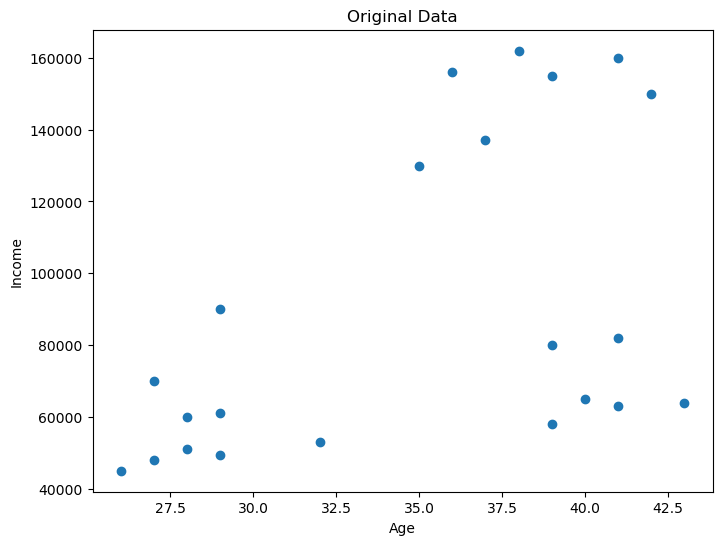

In [ ]:
# plotting original datapoints 
plt.figure(figsize=(8,6))
plt.scatter(df["Age"], df["Income($)"])

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("Original Data")

plt.show()

In [5]:
# Select features
X = df[["Age", "Income($)"]].values

In [6]:
# Min-Max Scaling

X_scaled = X.copy().astype(float)

X_scaled[:, 0] = (X[:, 0] - X[:, 0].min()) / (X[:, 0].max() - X[:, 0].min())
X_scaled[:, 1] = (X[:, 1] - X[:, 1].min()) / (X[:, 1].max() - X[:, 1].min())

In [ ]:
k = 3

# Smart initialization 
sorted_X = X_scaled[X_scaled[:,1].argsort()]

centroids = np.array([
    sorted_X[0],
    sorted_X[len(X_scaled)//2],
    sorted_X[-1]
])

centroids

array([[0.        , 0.        ],
       [0.05882353, 0.21367521],
       [0.70588235, 1.        ]])

In [ ]:

# function of assigning cluster to each point 
def assign_clusters(X, centroids):
    clusters = []
    
    for point in X:
        distances = []
        
        for centroid in centroids:
            distance = np.sqrt((point[0] - centroid[0])**2 + (point[1] - centroid[1])**2)
            distances.append(distance)
        
        cluster = np.argmin(distances)
        clusters.append(cluster)
    
    return np.array(clusters)

In [ ]:
# updting centeroids 
def update_centroids(X, clusters, k):
    new_centroids = []
    
    for i in range(k):
        cluster_points = X[clusters == i]
        centroid = np.mean(cluster_points, axis=0)
        new_centroids.append(centroid)
    
    return np.array(new_centroids)

In [ ]:
# Repeat the process untill convergence 
max_iters = 100

for i in range(max_iters):
    
    clusters = assign_clusters(X_scaled, centroids)
    new_centroids = update_centroids(X_scaled, clusters, k)
    
    if np.all(centroids == new_centroids):
        print(f"Converged in {i} iterations")
        break
    
    centroids = new_centroids

Converged in 3 iterations


In [13]:
# rescale the centerids 
centroids_original = np.zeros_like(centroids)

centroids_original[:, 0] = centroids[:, 0] * (X[:,0].max() - X[:,0].min()) + X[:,0].min()
centroids_original[:, 1] = centroids[:, 1] * (X[:,1].max() - X[:,1].min()) + X[:,1].min()

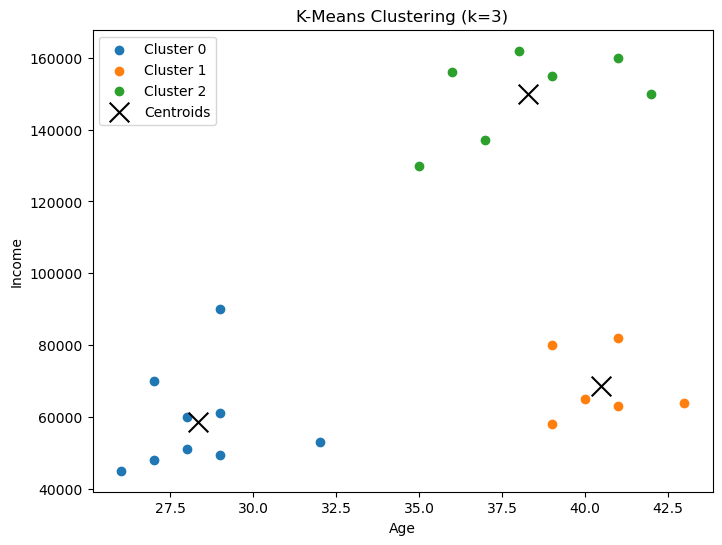

In [12]:
plt.figure(figsize=(8,6))

for i in range(k):
    points = X[clusters == i]
    plt.scatter(points[:, 0], points[:, 1], label=f"Cluster {i}")

plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            color='black', marker='x', s=200, label='Centroids')

plt.xlabel("Age")
plt.ylabel("Income")
plt.title("K-Means Clustering (k=3)")
plt.legend()

plt.show()